<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3027 acc 0.402 | val loss 1.1002 acc 0.557 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.9674 acc 0.599 | val loss 0.8056 acc 0.714 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.7754 acc 0.665 | val loss 0.6410 acc 0.764 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5781 acc 0.694 | val loss 0.5323 acc 0.759 *


...

[EfficientNet-B0] Epoch  21/100 | LR: 1.00e-05 | train loss 0.1339 acc 0.937 | val loss 0.4240 acc 0.862


[EfficientNet-B0] Epoch  22/100 | LR: 1.00e-05 | train loss 0.1352 acc 0.925 | val loss 0.4149 acc 0.862


[EfficientNet-B0] Epoch  23/100 | LR: 1.00e-05 | train loss 0.1403 acc 0.925 | val loss 0.4460 acc 0.837


[EfficientNet-B0] Epoch  24/100 | LR: 1.00e-05 | train loss 0.1430 acc 0.923 | val loss 0.4535 acc 0.833


[EfficientNet-B0] Epoch  25/100 | LR: 1.00e-05 | train loss 0.1187 acc 0.943 | val loss 0.4335 acc 0.837

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 25.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3898)


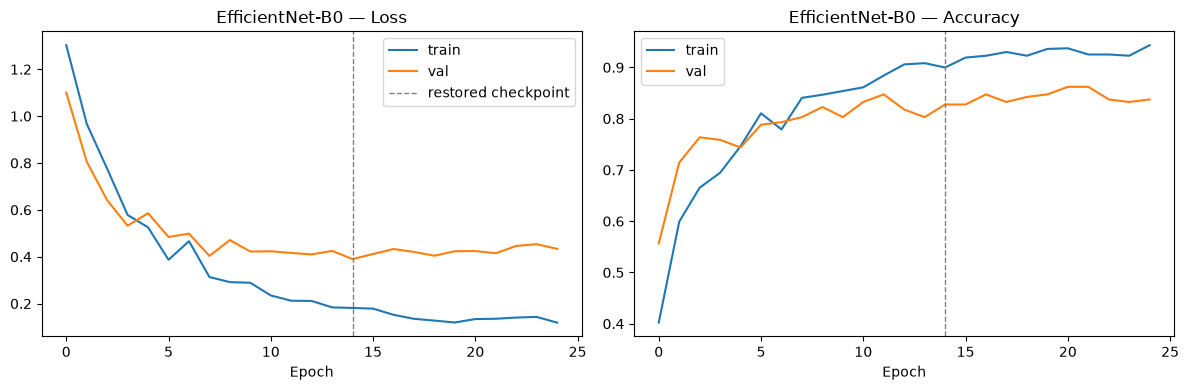

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.603


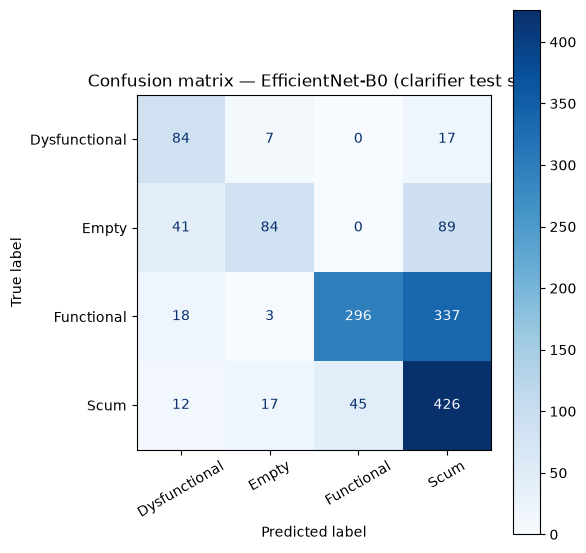

               precision    recall  f1-score   support

Dysfunctional      0.542     0.778     0.639       108
        Empty      0.757     0.393     0.517       214
   Functional      0.868     0.453     0.595       654
         Scum      0.490     0.852     0.622       500

     accuracy                          0.603      1476
    macro avg      0.664     0.619     0.593      1476
 weighted avg      0.700     0.603     0.596      1476



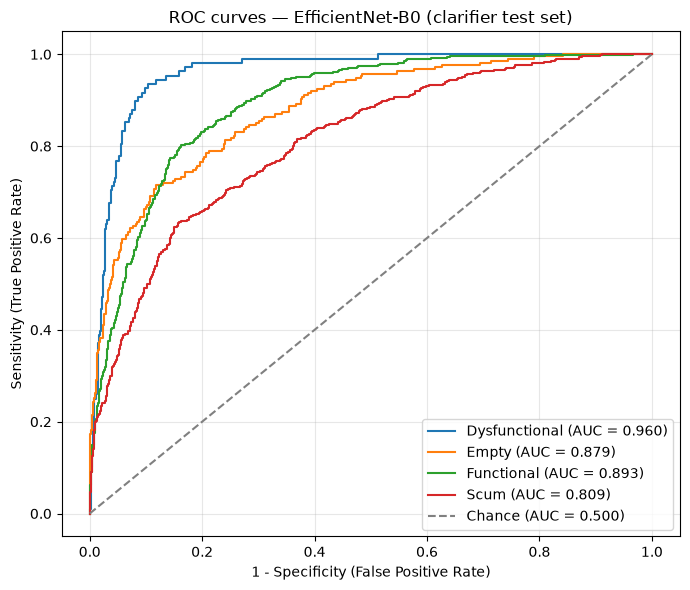

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.960
  Empty          : 0.879
  Functional     : 0.893
  Scum           : 0.809

Mean AUC (over 4/4 classes with test examples): 0.885


(np.float64(0.6029810298102981),
 {'Dysfunctional': 0.9595110461338532,
  'Empty': 0.8793600130337546,
  'Functional': 0.8928770731489544,
  'Scum': 0.8088831967213115})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_CapeFlats.pkl
Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
